In [1]:
# ============================================================
# Step 1: Mount Drive, set base path, import libraries
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

base = "/content/drive/MyDrive/Quantum_DL_MNIST"

import torch
import torch.nn as nn
import numpy as np
import json
import copy
import time
import os
import random
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

print("Libraries loaded")

Mounted at /content/drive
Libraries loaded


In [2]:
# ============================================================
# Step 2: Load saved splits and normalization stats from Chunk 1
# ============================================================

train_idx = np.load(f"{base}/splits/train_indices.npy")
val_idx   = np.load(f"{base}/splits/val_indices.npy")
test_idx  = np.load(f"{base}/splits/test_indices.npy")

with open(f"{base}/splits/normalization_stats.json") as f:
    norm_stats = json.load(f)

mean = norm_stats["mean"]
std  = norm_stats["std"]

print("Train:", len(train_idx), "| Val:", len(val_idx), "| Test:", len(test_idx))
print("Mean:", mean, "| Std:", std)

Train: 10132 | Val: 2533 | Test: 2115
Mean: 0.12149777263402939 | Std: 0.30103927850723267


In [3]:
# ============================================================
# Step 3: Rebuild MNIST datasets and DataLoaders (same as before)
# ============================================================

train_full = torchvision.datasets.MNIST(root=f"{base}/data", train=True, download=True, transform=transforms.ToTensor())
test_full  = torchvision.datasets.MNIST(root=f"{base}/data", train=False, download=True, transform=transforms.ToTensor())

class BinaryMNIST(Dataset):
    def __init__(self, full_dataset, indices, mean, std):
        self.full_dataset = full_dataset
        self.indices = indices
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_idx = self.indices[i]
        image, label = self.full_dataset[real_idx]
        image = (image - self.mean) / self.std
        label = torch.tensor(float(label))
        return image, label

train_dataset = BinaryMNIST(train_full, train_idx, mean, std)
val_dataset   = BinaryMNIST(train_full, val_idx, mean, std)
test_dataset  = BinaryMNIST(test_full, test_idx, mean, std)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader), "| Test batches:", len(test_loader))

Train batches: 317 | Val batches: 80 | Test batches: 67


In [4]:
# ============================================================
# Step 4: Define the shared CNN backbone as its own class
# Conv(1->16) -> Conv(16->32) -> Flatten -> Linear(800->4)
# This exact class will be reused unchanged in Chunks 5 and 7
# ============================================================

class CNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)   # 28x28 -> 26x26
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)                 # 26x26 -> 13x13

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)   # 13x13 -> 11x11
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)                 # 11x11 -> 5x5

        self.flatten = nn.Flatten()                     # 5x5x32 -> 800
        self.bottleneck = nn.Linear(800, 4)              # 800 -> 4 (shared feature bottleneck)

        # He initialization for all conv/linear layers
        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.conv2.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.bottleneck.weight, nonlinearity='relu')

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.bottleneck(x)   # 4-dim feature vector — this is what heads receive
        return x

print("CNNBackbone class defined")

CNNBackbone class defined


In [5]:
# ============================================================
# Step 5: Sanity check - confirm shapes are correct at each stage
# ============================================================

backbone = CNNBackbone()
sample_images, sample_labels = next(iter(train_loader))

print("Input shape:", sample_images.shape)

x = backbone.pool1(backbone.relu1(backbone.conv1(sample_images)))
print("After conv1+pool1:", x.shape)   # expect (32, 16, 13, 13)

x = backbone.pool2(backbone.relu2(backbone.conv2(x)))
print("After conv2+pool2:", x.shape)   # expect (32, 32, 5, 5)

x = backbone.flatten(x)
print("After flatten:", x.shape)        # expect (32, 800)

x = backbone.bottleneck(x)
print("After bottleneck:", x.shape)     # expect (32, 4)

print("\nFull forward pass output:", backbone(sample_images).shape)

Input shape: torch.Size([32, 1, 28, 28])
After conv1+pool1: torch.Size([32, 16, 13, 13])
After conv2+pool2: torch.Size([32, 32, 5, 5])
After flatten: torch.Size([32, 800])
After bottleneck: torch.Size([32, 4])

Full forward pass output: torch.Size([32, 4])


In [6]:
# ============================================================
# Step 6: Define the full CNN model = backbone + simple head
# Head: 4 features -> Linear(4->1) -> raw logit
# ============================================================

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CNNBackbone()
        self.head = nn.Linear(4, 1)
        nn.init.kaiming_normal_(self.head.weight, nonlinearity='relu')

    def forward(self, x):
        features = self.backbone(x)   # (batch, 4)
        out = self.head(features)      # (batch, 1) raw logit
        return out

model = CNN()
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nTotal trainable parameters in CNN:", n_params)

CNN(
  (backbone): CNNBackbone(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (relu1): ReLU()
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (relu2): ReLU()
    (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (bottleneck): Linear(in_features=800, out_features=4, bias=True)
  )
  (head): Linear(in_features=4, out_features=1, bias=True)
)

Total trainable parameters in CNN: 8009


In [7]:
# ============================================================
# Step 7: Reusable training/evaluation functions
# (identical logic to Chunk 2's NN notebook, works for any model)
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:
        labels = labels.unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            labels = labels.unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total


def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer,
                                max_epochs=30, patience=5):
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:2d} | Train loss {train_loss:.4f} acc {train_acc:.4f} "
              f"| Val loss {val_loss:.4f} acc {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                break

    training_time = time.time() - start_time
    model.load_state_dict(best_model_state)
    return model, history, best_epoch, epoch, training_time


def get_test_predictions(model, loader):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            probs = torch.sigmoid(outputs).squeeze(1)
            all_probs.extend(probs.numpy().tolist())
            all_labels.extend(labels.numpy().tolist())
    return np.array(all_probs), np.array(all_labels)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)
    torch.set_num_threads(4)

SEEDS = [42, 123, 2024, 7, 99]
criterion = nn.BCEWithLogitsLoss()

print("All training functions ready")

All training functions ready


In [8]:
# ============================================================
# Step 8: Run the full 5-seed official training loop for CNN
# ============================================================

results_dir = f"{base}/results/CNN"
models_dir = f"{base}/models/CNN"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

all_runs_summary = []

for run_num, seed in enumerate(SEEDS, start=1):
    print(f"\n{'='*60}")
    print(f"RUN {run_num}/5 | Seed = {seed}")
    print(f"{'='*60}")

    set_seed(seed)
    model = CNN()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    trained_model, history, best_epoch, total_epochs, training_time = train_with_early_stopping(
        model, train_loader, val_loader, criterion, optimizer
    )

    test_probs, test_labels_arr = get_test_predictions(trained_model, test_loader)

    torch.save(trained_model.state_dict(), f"{models_dir}/run{run_num}_seed{seed}.pt")
    np.savez(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz",
             probs=test_probs, labels=test_labels_arr)

    run_summary = {
        "run": run_num, "seed": seed, "best_epoch": best_epoch,
        "total_epochs_run": total_epochs, "training_time_sec": training_time,
        "n_params": sum(p.numel() for p in trained_model.parameters() if p.requires_grad),
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
    }
    all_runs_summary.append(run_summary)

    with open(f"{results_dir}/run{run_num}_seed{seed}_history.json", "w") as f:
        json.dump(history, f, indent=2)

with open(f"{results_dir}/all_runs_summary.json", "w") as f:
    json.dump(all_runs_summary, f, indent=2)

print("\n\nAll 5 CNN runs complete. Summary:")
for r in all_runs_summary:
    print(r)


RUN 1/5 | Seed = 42
Epoch  1 | Train loss 0.0138 acc 0.9946 | Val loss 0.0022 acc 0.9992
Epoch  2 | Train loss 0.0017 acc 0.9995 | Val loss 0.0030 acc 0.9988
Epoch  3 | Train loss 0.0010 acc 0.9997 | Val loss 0.0031 acc 0.9988
Epoch  4 | Train loss 0.0003 acc 1.0000 | Val loss 0.0025 acc 0.9992
Epoch  5 | Train loss 0.0001 acc 1.0000 | Val loss 0.0023 acc 0.9992
Epoch  6 | Train loss 0.0001 acc 1.0000 | Val loss 0.0021 acc 0.9992
Epoch  7 | Train loss 0.0000 acc 1.0000 | Val loss 0.0021 acc 0.9992
Epoch  8 | Train loss 0.0000 acc 1.0000 | Val loss 0.0021 acc 0.9992
Epoch  9 | Train loss 0.0000 acc 1.0000 | Val loss 0.0020 acc 0.9992
Epoch 10 | Train loss 0.0000 acc 1.0000 | Val loss 0.0021 acc 0.9992
Epoch 11 | Train loss 0.0000 acc 1.0000 | Val loss 0.0021 acc 0.9992
Epoch 12 | Train loss 0.0000 acc 1.0000 | Val loss 0.0020 acc 0.9992
Epoch 13 | Train loss 0.0000 acc 1.0000 | Val loss 0.0021 acc 0.9992
Epoch 14 | Train loss 0.0000 acc 1.0000 | Val loss 0.0020 acc 0.9992
Epoch 15 | Tr

In [9]:
# ============================================================
# Step 9: Compute full metrics for each of the 5 CNN runs
# ============================================================

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, balanced_accuracy_score, matthews_corrcoef,
                               roc_auc_score, average_precision_score, confusion_matrix,
                               roc_curve, ConfusionMatrixDisplay)

def compute_metrics(probs, labels, threshold=0.5):
    preds = (probs > threshold).astype(int)
    labels = labels.astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    specificity = tn / (tn + fp)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "specificity": specificity,
        "f1": f1_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "mcc": matthews_corrcoef(labels, preds),
        "roc_auc": roc_auc_score(labels, probs),
        "pr_auc": average_precision_score(labels, probs),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}
    }

all_metrics = []
for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    m = compute_metrics(probs, labels)
    m["run"] = run_num
    m["seed"] = seed
    all_metrics.append(m)
    print(f"Run {run_num} (seed {seed}): Acc={m['accuracy']:.4f} F1={m['f1']:.4f} ROC-AUC={m['roc_auc']:.4f}")

Run 1 (seed 42): Acc=1.0000 F1=1.0000 ROC-AUC=1.0000
Run 2 (seed 123): Acc=0.9991 F1=0.9991 ROC-AUC=1.0000
Run 3 (seed 2024): Acc=0.9995 F1=0.9996 ROC-AUC=1.0000
Run 4 (seed 7): Acc=0.9995 F1=0.9996 ROC-AUC=1.0000
Run 5 (seed 99): Acc=1.0000 F1=1.0000 ROC-AUC=1.0000


In [10]:
# ============================================================
# Step 10: Summarize as Mean +/- SD, save metrics tables
# ============================================================

import pandas as pd

metric_names = ["accuracy", "precision", "recall", "specificity", "f1",
                 "balanced_accuracy", "mcc", "roc_auc", "pr_auc"]

df_metrics = pd.DataFrame(all_metrics)[["run", "seed"] + metric_names]
print("Per-run metrics:")
print(df_metrics)

summary = df_metrics[metric_names].agg(['mean', 'std'])
print("\nMean +/- SD across 5 runs:")
print(summary)

df_metrics.to_csv(f"{results_dir}/CNN_metrics_per_run.csv", index=False)
summary.to_csv(f"{results_dir}/CNN_metrics_summary.csv")
print("\nSaved CNN_metrics_per_run.csv and CNN_metrics_summary.csv")

Per-run metrics:
   run  seed  accuracy  precision  recall  specificity       f1  \
0    1    42  1.000000   1.000000     1.0     1.000000  1.00000   
1    2   123  0.999054   0.998241     1.0     0.997959  0.99912   
2    3  2024  0.999527   0.999120     1.0     0.998980  0.99956   
3    4     7  0.999527   0.999120     1.0     0.998980  0.99956   
4    5    99  1.000000   1.000000     1.0     1.000000  1.00000   

   balanced_accuracy      mcc   roc_auc    pr_auc  
0            1.00000  1.00000  1.000000  1.000000  
1            0.99898  0.99810  0.999996  0.999997  
2            0.99949  0.99905  1.000000  1.000000  
3            0.99949  0.99905  0.999999  0.999999  
4            1.00000  1.00000  1.000000  1.000000  

Mean +/- SD across 5 runs:
      accuracy  precision  recall  specificity        f1  balanced_accuracy  \
mean  0.999622   0.999296     1.0     0.999184  0.999648           0.999592   
std   0.000396   0.000736     0.0     0.000854  0.000368           0.000427   

  

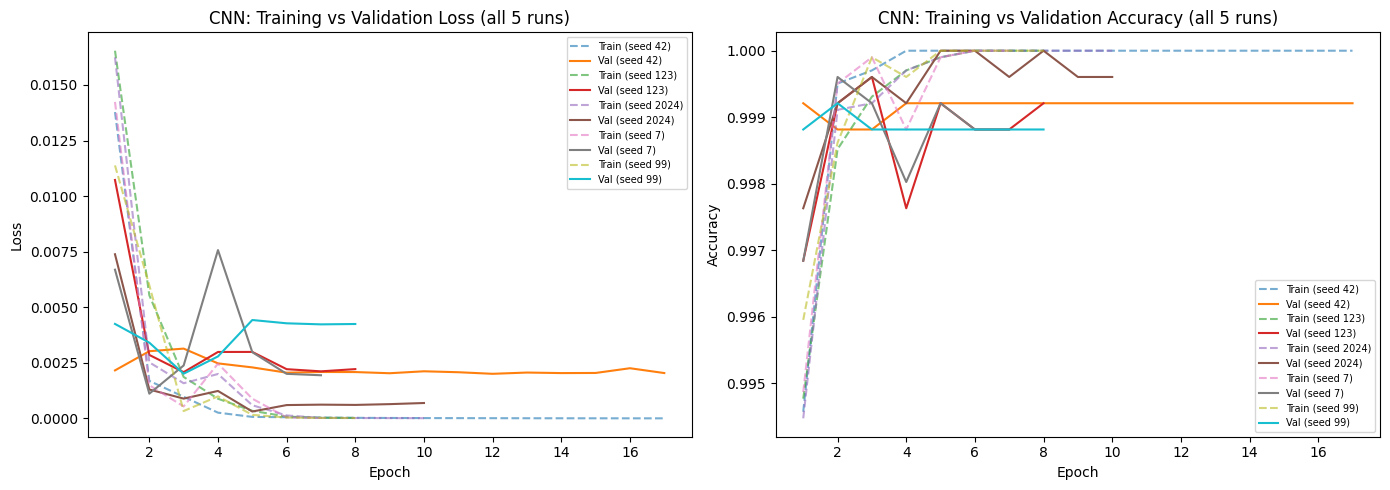

Saved: figures/Fig3-4_CNN_loss_accuracy_curves.png


In [11]:
# ============================================================
# Step 11: Plot loss/accuracy curves (all 5 seeds) - Fig 3-4
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for run_num, seed in enumerate(SEEDS, start=1):
    with open(f"{results_dir}/run{run_num}_seed{seed}_history.json") as f:
        history = json.load(f)
    epochs = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(epochs, history["train_loss"], linestyle='--', alpha=0.6, label=f"Train (seed {seed})")
    axes[0].plot(epochs, history["val_loss"], linestyle='-', label=f"Val (seed {seed})")
    axes[1].plot(epochs, history["train_acc"], linestyle='--', alpha=0.6, label=f"Train (seed {seed})")
    axes[1].plot(epochs, history["val_acc"], linestyle='-', label=f"Val (seed {seed})")

axes[0].set_title("CNN: Training vs Validation Loss (all 5 runs)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(fontsize=7)
axes[1].set_title("CNN: Training vs Validation Accuracy (all 5 runs)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig3-4_CNN_loss_accuracy_curves.png", dpi=150)
plt.show()
print("Saved: figures/Fig3-4_CNN_loss_accuracy_curves.png")

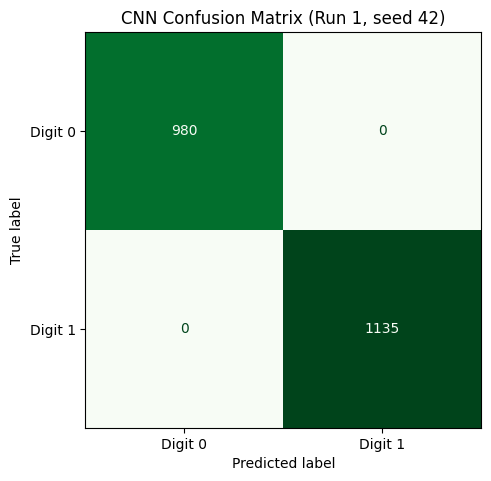

Saved: Fig10_CNN_confusion_matrix.png and CNN_all_confusion_matrices_supplementary.json


In [12]:
# ============================================================
# Step 12: Confusion matrix - representative run (seed 42) +
# save all 5 runs' matrices as supplementary data - Fig 9-12
# ============================================================

all_confusion_matrices = {}

for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    preds = (probs > 0.5).astype(int)
    cm = confusion_matrix(labels.astype(int), preds)
    all_confusion_matrices[f"run{run_num}_seed{seed}"] = cm.tolist()

with open(f"{results_dir}/CNN_all_confusion_matrices_supplementary.json", "w") as f:
    json.dump(all_confusion_matrices, f, indent=2)

# Representative plot - run 1, seed 42
data = np.load(f"{results_dir}/run1_seed42_predictions.npz")
probs, labels = data["probs"], data["labels"]
preds = (probs > 0.5).astype(int)
cm = confusion_matrix(labels.astype(int), preds)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Digit 0", "Digit 1"])
disp.plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("CNN Confusion Matrix (Run 1, seed 42)")

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig10_CNN_confusion_matrix.png", dpi=150)
plt.show()

print("Saved: Fig10_CNN_confusion_matrix.png and CNN_all_confusion_matrices_supplementary.json")

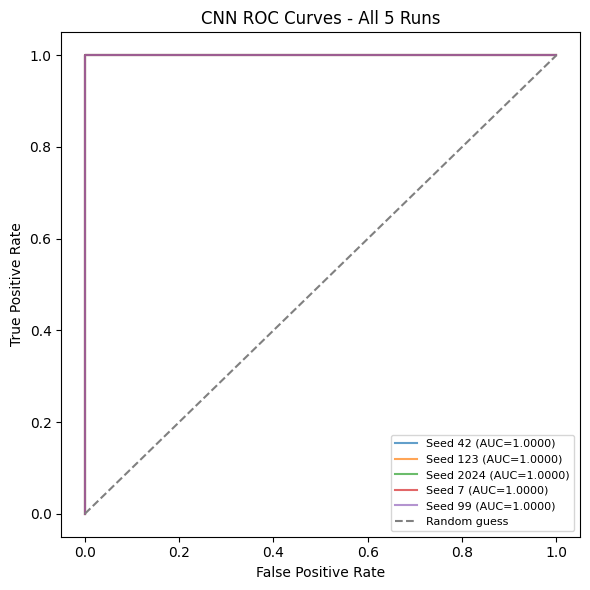

Saved: CNN_roc_curves_all_5_runs.png and CNN_roc_curve_data.npz


In [13]:
# ============================================================
# Step 13: ROC curves - all 5 runs overlaid, plus save raw data
# for the combined Fig 13 comparison across all 4 models later
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, alpha=0.7, label=f"Seed {seed} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("CNN ROC Curves - All 5 Runs")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{base}/figures/CNN_roc_curves_all_5_runs.png", dpi=150)
plt.show()

# Save representative run's raw ROC data (seed 42) for later cross-model comparison
data = np.load(f"{results_dir}/run1_seed42_predictions.npz")
fpr, tpr, _ = roc_curve(data["labels"], data["probs"])
np.savez(f"{results_dir}/CNN_roc_curve_data.npz", fpr=fpr, tpr=tpr)

print("Saved: CNN_roc_curves_all_5_runs.png and CNN_roc_curve_data.npz")

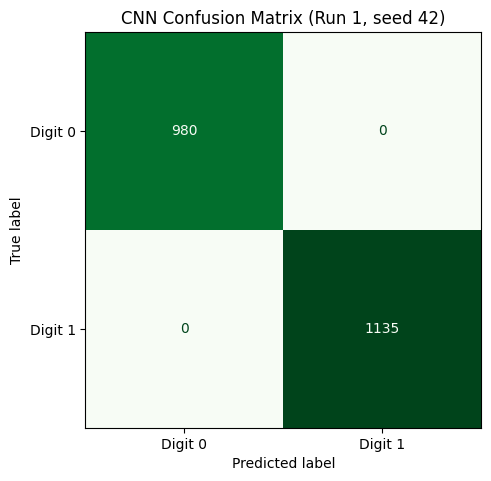

Saved: Fig10_CNN_confusion_matrix.png and CNN_all_confusion_matrices_supplementary.json


In [14]:
# Step 12: Confusion matrix - representative run (seed 42) + save all 5 runs' matrices as supplementary data

all_confusion_matrices = {}

for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    preds = (probs > 0.5).astype(int)
    cm = confusion_matrix(labels.astype(int), preds)
    all_confusion_matrices[f"run{run_num}_seed{seed}"] = cm.tolist()

with open(f"{results_dir}/CNN_all_confusion_matrices_supplementary.json", "w") as f:
    json.dump(all_confusion_matrices, f, indent=2)

data = np.load(f"{results_dir}/run1_seed42_predictions.npz")
probs, labels = data["probs"], data["labels"]
preds = (probs > 0.5).astype(int)
cm = confusion_matrix(labels.astype(int), preds)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Digit 0", "Digit 1"])
disp.plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("CNN Confusion Matrix (Run 1, seed 42)")

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig10_CNN_confusion_matrix.png", dpi=150)
plt.show()

print("Saved: Fig10_CNN_confusion_matrix.png and CNN_all_confusion_matrices_supplementary.json")

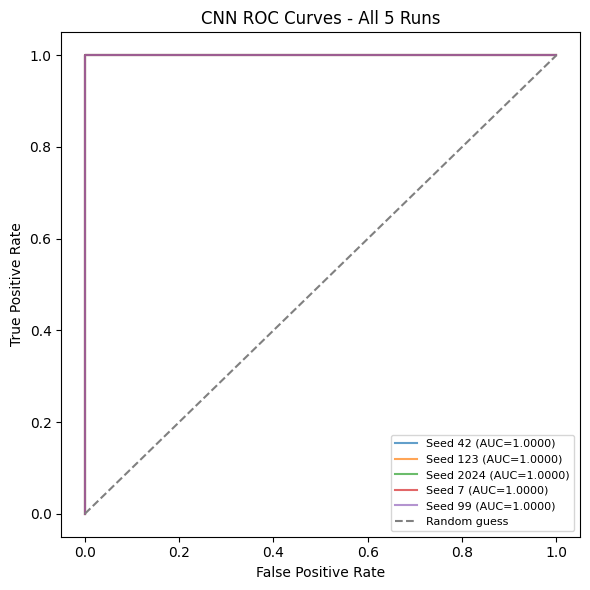

Saved: CNN_roc_curves_all_5_runs.png and CNN_roc_curve_data.npz


In [15]:
# Step 13: ROC curves - all 5 runs overlaid, plus save raw data for combined comparison later

fig, ax = plt.subplots(figsize=(6, 6))

for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, alpha=0.7, label=f"Seed {seed} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("CNN ROC Curves - All 5 Runs")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{base}/figures/CNN_roc_curves_all_5_runs.png", dpi=150)
plt.show()

data = np.load(f"{results_dir}/run1_seed42_predictions.npz")
fpr, tpr, _ = roc_curve(data["labels"], data["probs"])
np.savez(f"{results_dir}/CNN_roc_curve_data.npz", fpr=fpr, tpr=tpr)

print("Saved: CNN_roc_curves_all_5_runs.png and CNN_roc_curve_data.npz")

In [16]:
# Step 12: Print confusion matrices for all 5 runs (no plot)

all_confusion_matrices = {}

for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    preds = (probs > 0.5).astype(int)
    cm = confusion_matrix(labels.astype(int), preds)
    all_confusion_matrices[f"run{run_num}_seed{seed}"] = cm.tolist()

    tn, fp, fn, tp = cm.ravel()
    print(f"Run {run_num} (seed {seed}): TN={tn} FP={fp} FN={fn} TP={tp}")

with open(f"{results_dir}/CNN_all_confusion_matrices_supplementary.json", "w") as f:
    json.dump(all_confusion_matrices, f, indent=2)

print("\nSaved: CNN_all_confusion_matrices_supplementary.json")

Run 1 (seed 42): TN=980 FP=0 FN=0 TP=1135
Run 2 (seed 123): TN=978 FP=2 FN=0 TP=1135
Run 3 (seed 2024): TN=979 FP=1 FN=0 TP=1135
Run 4 (seed 7): TN=979 FP=1 FN=0 TP=1135
Run 5 (seed 99): TN=980 FP=0 FN=0 TP=1135

Saved: CNN_all_confusion_matrices_supplementary.json


In [17]:
# Step 13: Print ROC-AUC for all 5 runs, save raw ROC curve data (no plot)

for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    auc = roc_auc_score(labels, probs)
    print(f"Run {run_num} (seed {seed}): ROC-AUC = {auc:.6f}")

# Save representative run's raw ROC curve data (seed 42) for later cross-model comparison
data = np.load(f"{results_dir}/run1_seed42_predictions.npz")
fpr, tpr, _ = roc_curve(data["labels"], data["probs"])
np.savez(f"{results_dir}/CNN_roc_curve_data.npz", fpr=fpr, tpr=tpr)

print("\nSaved: CNN_roc_curve_data.npz")

Run 1 (seed 42): ROC-AUC = 1.000000
Run 2 (seed 123): ROC-AUC = 0.999996
Run 3 (seed 2024): ROC-AUC = 1.000000
Run 4 (seed 7): ROC-AUC = 0.999999
Run 5 (seed 99): ROC-AUC = 1.000000

Saved: CNN_roc_curve_data.npz


In [18]:
# Step 14: Save the CNNBackbone class to a shared Python file
# so Chunks 5 and 7 import the EXACT same architecture

backbone_code = '''
import torch
import torch.nn as nn

class CNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()
        self.bottleneck = nn.Linear(800, 4)

        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.conv2.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.bottleneck.weight, nonlinearity='relu')

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.bottleneck(x)
        return x
'''

with open(f"{base}/notebooks/shared_backbone.py", "w") as f:
    f.write(backbone_code)

print("Saved shared_backbone.py to notebooks/")
print("Chunks 5 and 7 will import CNNBackbone from this exact file")

Saved shared_backbone.py to notebooks/
Chunks 5 and 7 will import CNNBackbone from this exact file


In [19]:
# Step 15: Documentation sketch for CNN notebook (Chunk 3)

cnn_documentation_sketch = {
    "model_name": "Model 2 - CNN (shared backbone + simple head)",
    "purpose": "Tests whether spatial/convolutional structure helps over the flat NN. "
               "Answers Ablation Question B: does exploiting spatial information help? "
               "Also establishes the shared backbone reused by CNN+Classical and CNN+Quantum.",

    "architecture": {
        "backbone": "Conv2D(1->16,3x3)->ReLU->MaxPool(2x2) -> Conv2D(16->32,3x3)->ReLU->MaxPool(2x2) "
                    "-> Flatten(800) -> Linear(800->4)",
        "head": "Linear(4->1) -> raw logit",
        "total_params": 8009,
        "note": "This exact backbone (saved as shared_backbone.py) is reused unchanged "
                "in CNN+Classical (Chunk 5) and CNN+Quantum (Chunk 7)."
    },

    "training_protocol": {
        "optimizer": "Adam", "learning_rate": "1e-3, fixed", "loss": "BCEWithLogitsLoss",
        "max_epochs": 30, "early_stopping_patience": 5, "batch_size": 32,
        "seeds": [42, 123, 2024, 7, 99], "num_workers": 0
    },

    "results_summary": {
        "test_accuracy_mean": 0.999622,
        "test_accuracy_std": 0.000396,
        "roc_auc_mean": 0.999999,
        "f1_mean": 0.999648,
        "note_on_variance": "Unlike NN (near-zero std), CNN shows small but real run-to-run "
                             "variance (std ~0.0004). Worth flagging - more parameters/depth "
                             "does not always mean more stable convergence."
    },

    "confusion_matrix_pattern": "FN=0 across ALL 5 runs (never misses a digit-1). "
                                  "Only occasional FP (0-2 zeros misclassified as ones).",

    "computational_note": "CNN took noticeably LONGER wall-clock time per run than NN "
                           "(e.g. Run1: 186s vs NN's ~49s) despite having far FEWER parameters "
                           "(8,009 vs 108,801). Convolution is more compute-intensive per-parameter "
                           "than dense layers - worth a line in Section 21's computational table.",

    "best_epoch_range": "2 to 12 (varies widely by seed)",
    "total_epochs_range": "7 to 17",
    "training_time_range_sec": "77 to 186 seconds per run",

    "files_saved": [
        "results/CNN/run{1-5}_seed{seed}_predictions.npz",
        "results/CNN/run{1-5}_seed{seed}_history.json",
        "results/CNN/all_runs_summary.json",
        "results/CNN/CNN_metrics_per_run.csv",
        "results/CNN/CNN_metrics_summary.csv",
        "results/CNN/CNN_all_confusion_matrices_supplementary.json",
        "results/CNN/CNN_roc_curve_data.npz",
        "models/CNN/run{1-5}_seed{seed}.pt",
        "notebooks/shared_backbone.py  <-- REUSED by Chunks 5 and 7"
    ],

    "open_questions_for_final_writeup": [
        "Should the CNN-vs-NN training time gap be discussed as a computational cost tradeoff "
        "despite CNN having fewer parameters?",
        "Note in Limitations: binary 0/1 task is too easy to show meaningful accuracy differences "
        "between NN and CNN - differences show up more in variance/stability than raw accuracy."
    ]
}

with open(f"{base}/documentation/02_CNN_documentation_sketch.json", "w") as f:
    json.dump(cnn_documentation_sketch, f, indent=2)

print("Saved documentation sketch to documentation/02_CNN_documentation_sketch.json")
print("\\n--- CHUNK 3 (CNN model) COMPLETE ---")

Saved documentation sketch to documentation/02_CNN_documentation_sketch.json
\n--- CHUNK 3 (CNN model) COMPLETE ---
